🔹 Task 1: Implement Decision Tree Classifier on Wine Dataset

Accuracy: 0.8518518518518519

Confusion Matrix:
 [[18  1  0]
 [ 2 17  2]
 [ 2  1 11]]

Classification Report:
               precision    recall  f1-score   support

     class_0       0.82      0.95      0.88        19
     class_1       0.89      0.81      0.85        21
     class_2       0.85      0.79      0.81        14

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



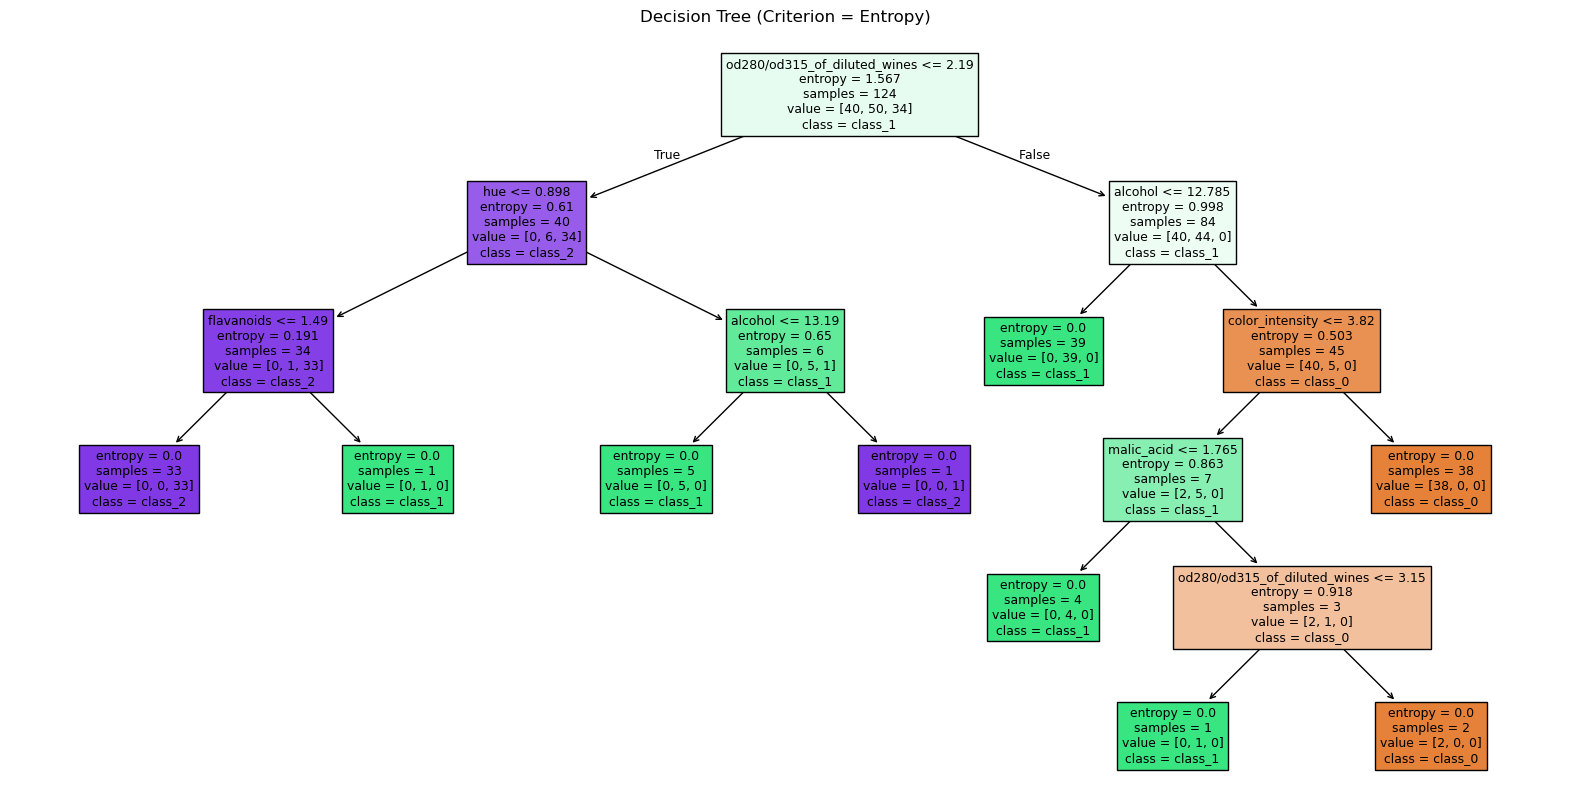

In [1]:
# Import required libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Step 2: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Decision Tree using entropy criterion
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

# Step 4: Predict on test set
y_pred = clf.predict(X_test)

# Step 5: Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

# Step 6: Visualize the trained decision tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True)
plt.title("Decision Tree (Criterion = Entropy)")
plt.show()


Accuracy: 0.9629629629629629

Confusion Matrix:
 [[18  1  0]
 [ 0 21  0]
 [ 1  0 13]]

Classification Report:
               precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



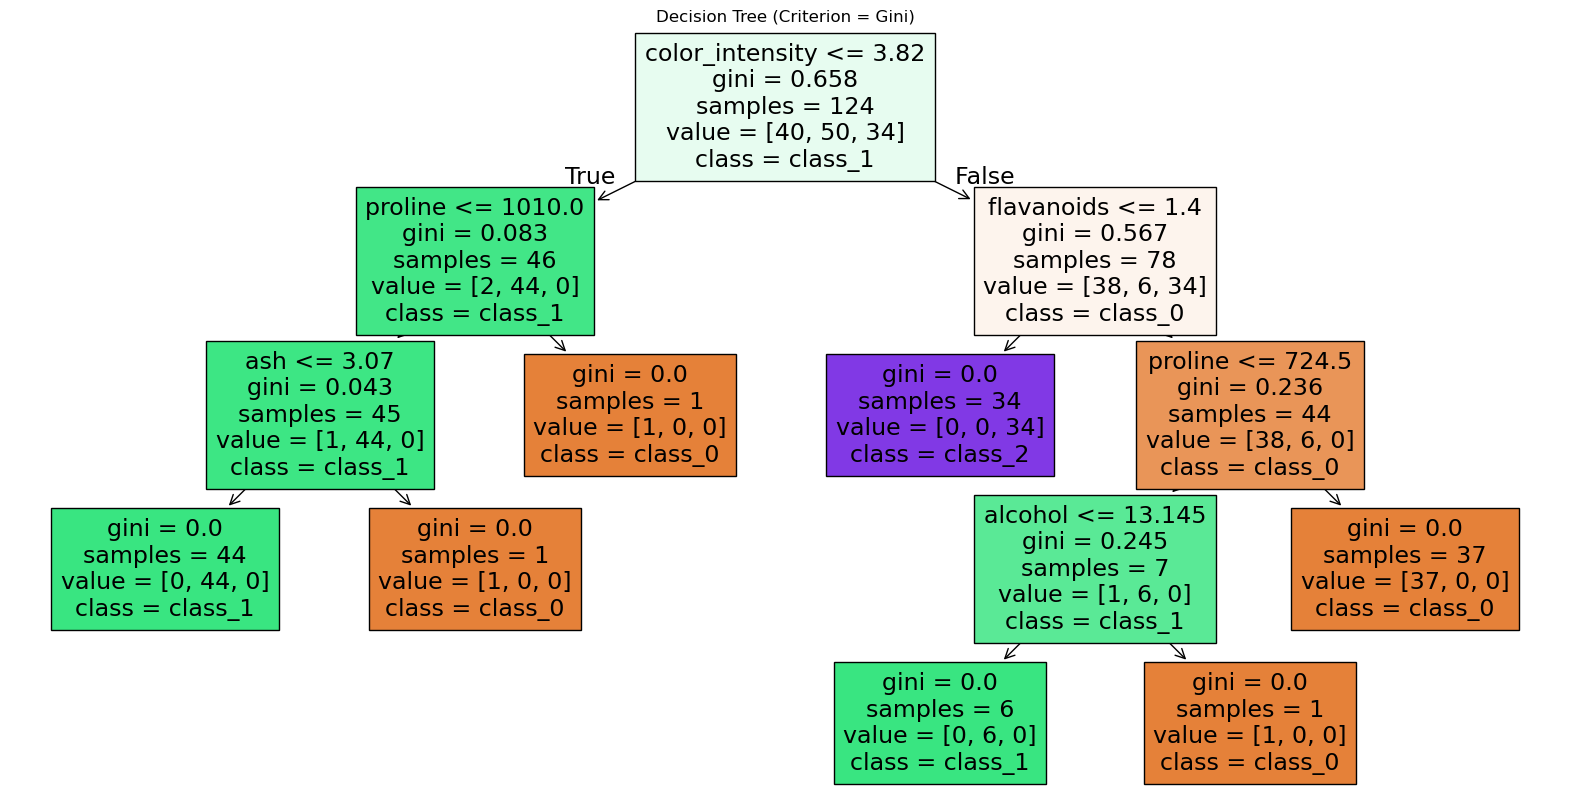

In [2]:
# Import required libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Load the Wine dataset
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Step 2: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Decision Tree using gini criterion
clf = DecisionTreeClassifier( random_state=42)
clf.fit(X_train, y_train)

# Step 4: Predict on test set
y_pred = clf.predict(X_test)

# Step 5: Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

# Step 6: Visualize the trained decision tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True)
plt.title("Decision Tree (Criterion = Gini)")
plt.show()


🌳 Task 2: Analyze the Effect of Tree Depth

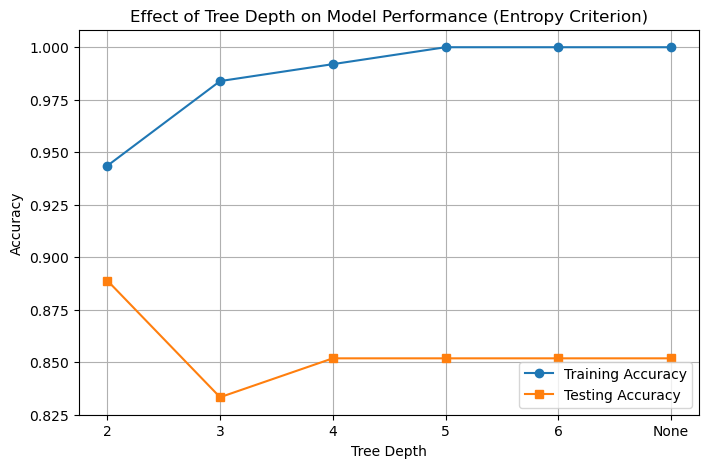

In [3]:
train_acc = []
test_acc = []
depths = [2, 3, 4, 5, 6, None]  # None = full depth

for depth in depths:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

# Plot accuracy vs depth
plt.figure(figsize=(8,5))
plt.plot([str(d) for d in depths], train_acc, marker='o', label='Training Accuracy')
plt.plot([str(d) for d in depths], test_acc, marker='s', label='Testing Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Effect of Tree Depth on Model Performance (Entropy Criterion)')
plt.legend()
plt.grid(True)
plt.show()


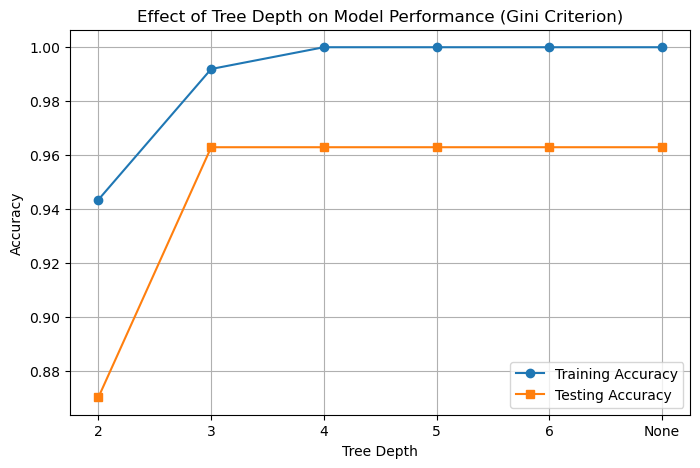

In [4]:
train_acc = []
test_acc = []
depths = [2, 3, 4, 5, 6, None]  # None = full depth

for depth in depths:
    model = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

# Plot accuracy vs depth
plt.figure(figsize=(8,5))
plt.plot([str(d) for d in depths], train_acc, marker='o', label='Training Accuracy')
plt.plot([str(d) for d in depths], test_acc, marker='s', label='Testing Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Effect of Tree Depth on Model Performance (Gini Criterion)')
plt.legend()
plt.grid(True)
plt.show()


Visualize Tree at Each Depth

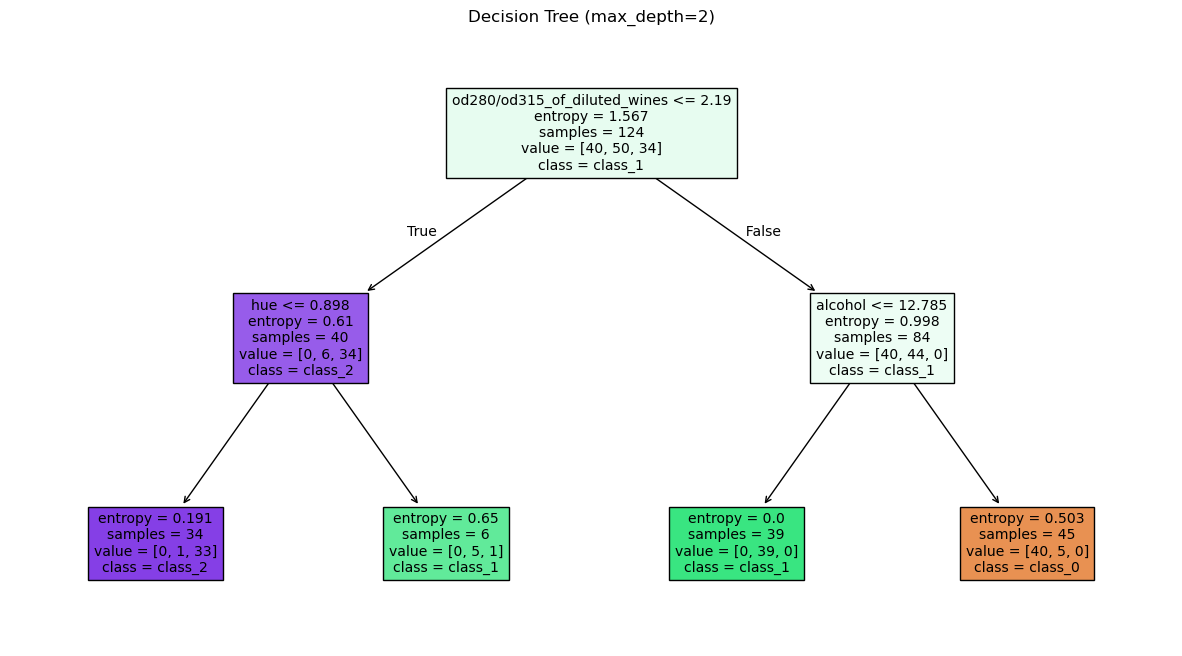

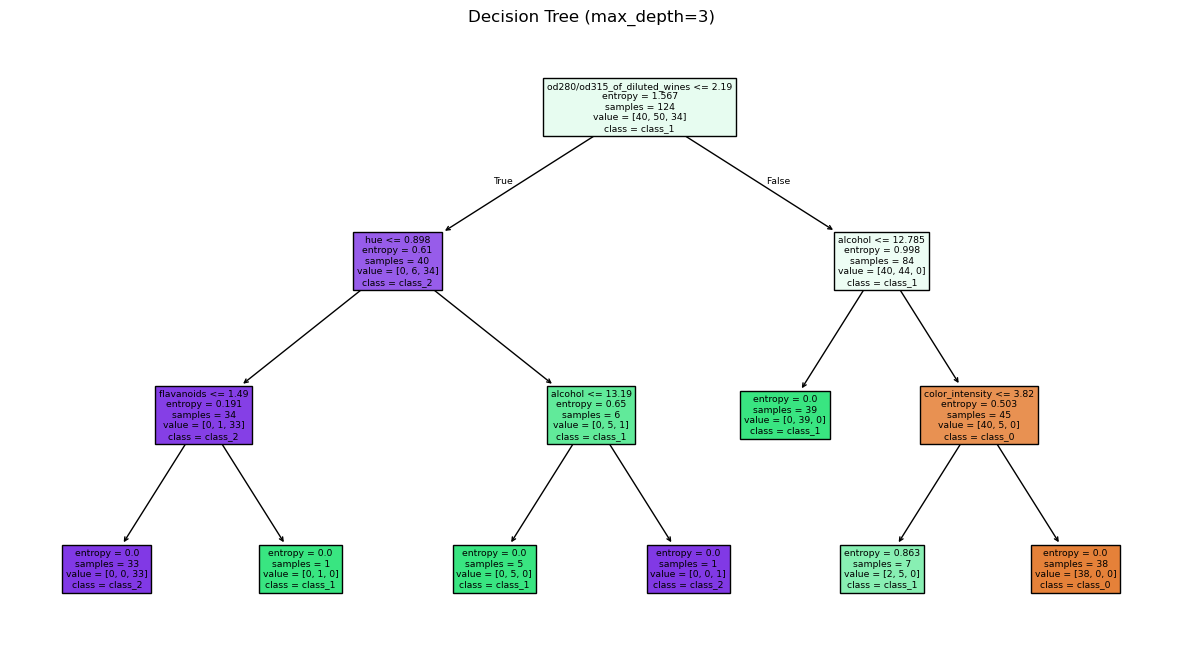

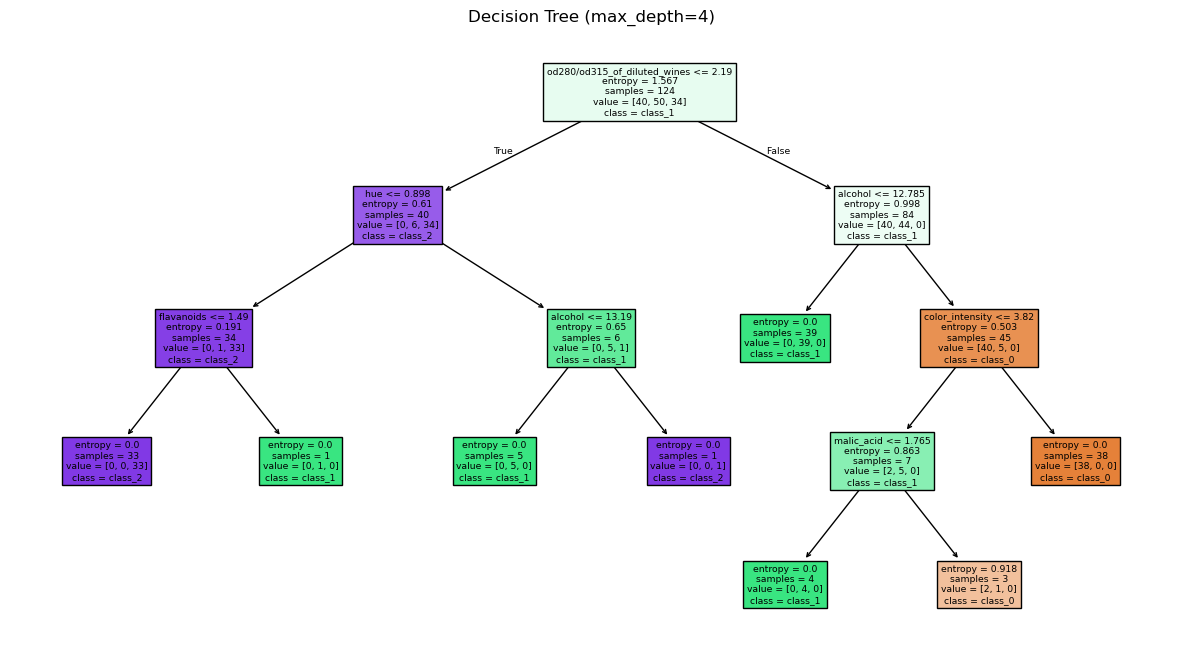

In [5]:
for d in [2, 3, 4]:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    plt.figure(figsize=(15,8))
    plot_tree(model, feature_names=feature_names, class_names=target_names, filled=True)
    plt.title(f"Decision Tree (max_depth={d})")
    plt.show()


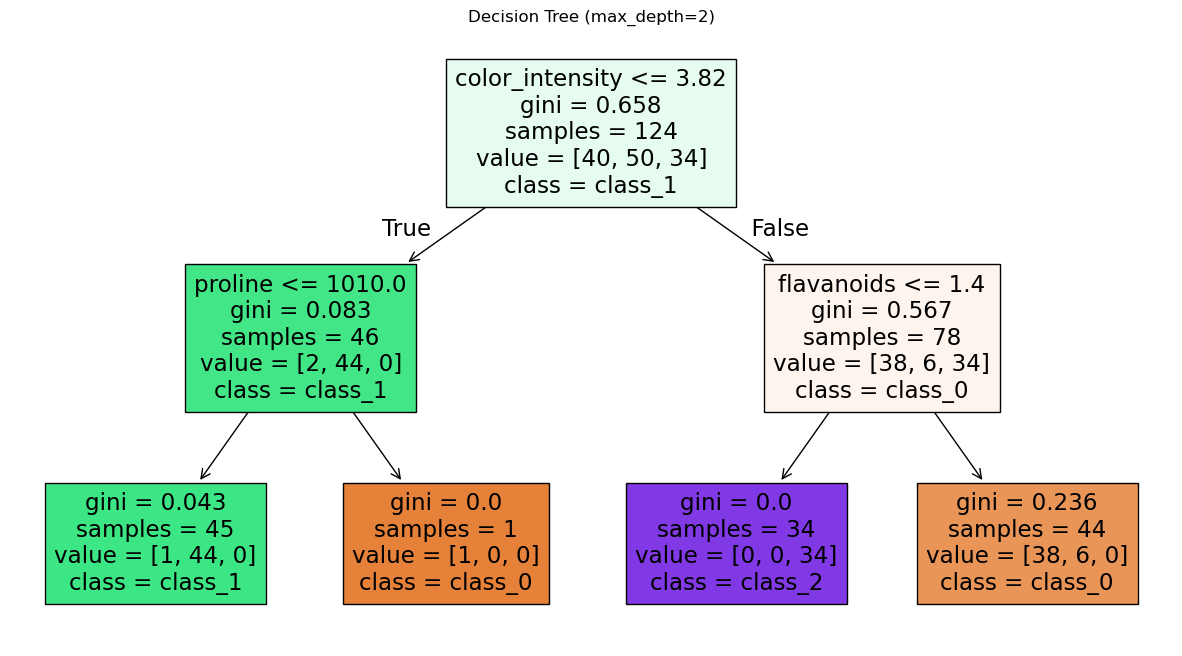

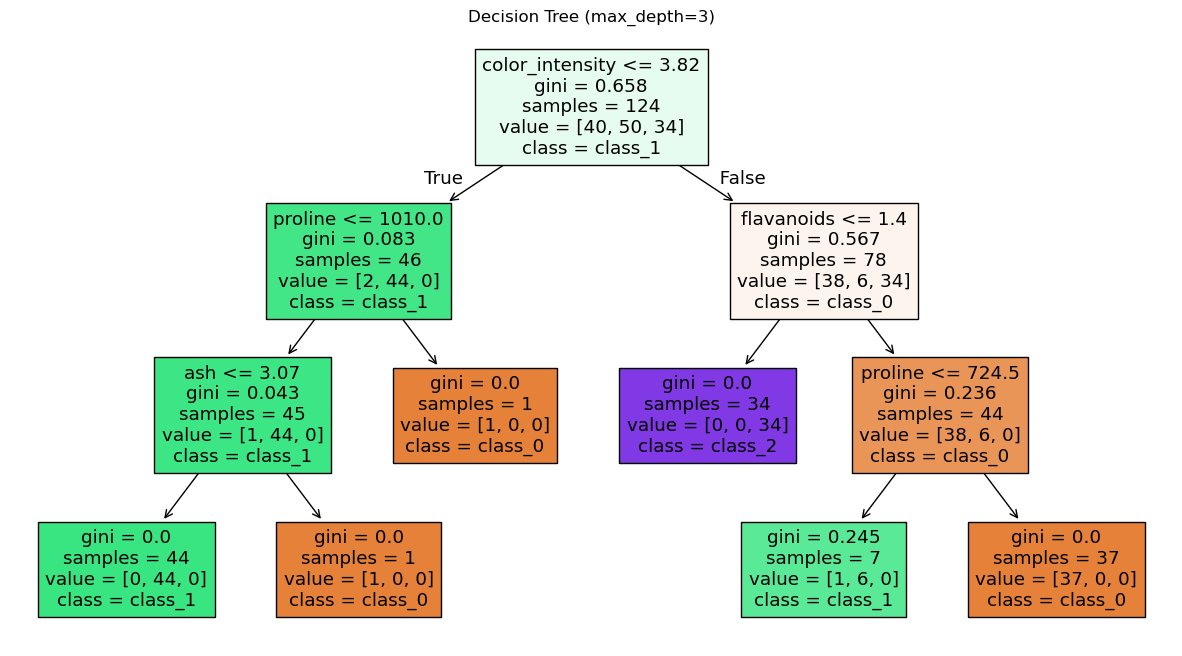

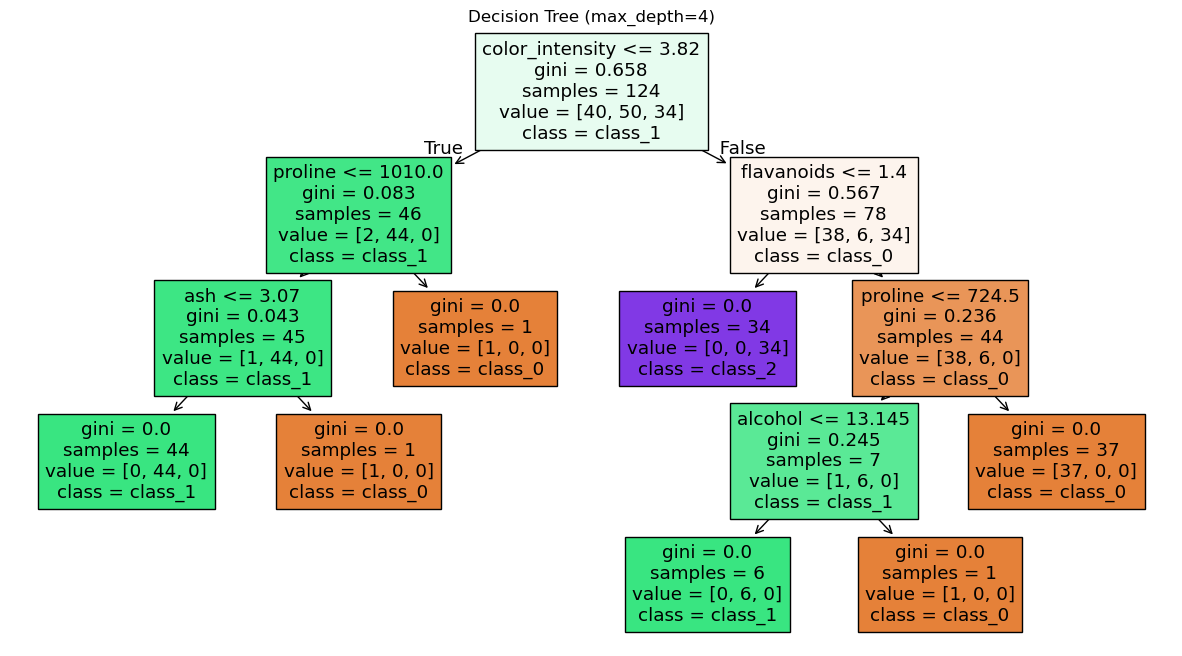

In [6]:
for d in [2, 3, 4]:
    model = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    plt.figure(figsize=(15,8))
    plot_tree(model, feature_names=feature_names, class_names=target_names, filled=True)
    plt.title(f"Decision Tree (max_depth={d})")
    plt.show()


Compare Gini vs Entropy Criteria

In [7]:
criteria = ['gini', 'entropy']
for crit in criteria:
    model = DecisionTreeClassifier(criterion=crit, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\nCriterion: {crit}")
    print("Accuracy:", accuracy_score(y_test, y_pred))



Criterion: gini
Accuracy: 0.9629629629629629

Criterion: entropy
Accuracy: 0.8518518518518519


🔍 Task 4: Effect of Feature Selection (with vs without all features)

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 6 most relevant features
selector = SelectKBest(score_func=f_classif, k=6)
X_new = selector.fit_transform(X, y)
selected_features = [feature_names[i] for i in selector.get_support(indices=True)]

print("Selected Features:", selected_features)

# Split again
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_new, y, test_size=0.3, random_state=42)

# Train model on reduced features
clf_sel = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_sel.fit(X_train_sel, y_train_sel)

# Evaluate performance
y_pred_sel = clf_sel.predict(X_test_sel)
print("\nAccuracy with selected features:", accuracy_score(y_test_sel, y_pred_sel))


Selected Features: ['alcohol', 'flavanoids', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Accuracy with selected features: 0.8703703703703703


🧩 Task 5: Compare Decision Tree with Random Forest 

In [9]:
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Decision Tree Accuracy:", dt.score(X_test, y_test))
print("Random Forest Accuracy:", rf.score(X_test, y_test))


Decision Tree Accuracy: 0.8518518518518519
Random Forest Accuracy: 1.0


Scaling vs No Scaling

In [10]:
# Import libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_wine()
X = data.data
y = data.target

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ---- WITHOUT SCALING ----
clf_raw = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_raw.fit(X_train, y_train)
y_pred_raw = clf_raw.predict(X_test)

acc_raw = accuracy_score(y_test, y_pred_raw)
print("Without Scaling Accuracy:", acc_raw)
print("Confusion Matrix (No Scaling):\n", confusion_matrix(y_test, y_pred_raw))
print()

# ---- WITH SCALING ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_scaled = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = clf_scaled.predict(X_test_scaled)

acc_scaled = accuracy_score(y_test, y_pred_scaled)
print("With Scaling Accuracy:", acc_scaled)
print("Confusion Matrix (With Scaling):\n", confusion_matrix(y_test, y_pred_scaled))


Without Scaling Accuracy: 0.8518518518518519
Confusion Matrix (No Scaling):
 [[18  1  0]
 [ 2 17  2]
 [ 2  1 11]]

With Scaling Accuracy: 0.8518518518518519
Confusion Matrix (With Scaling):
 [[18  1  0]
 [ 2 17  2]
 [ 2  1 11]]


Scaling Effect Plotted

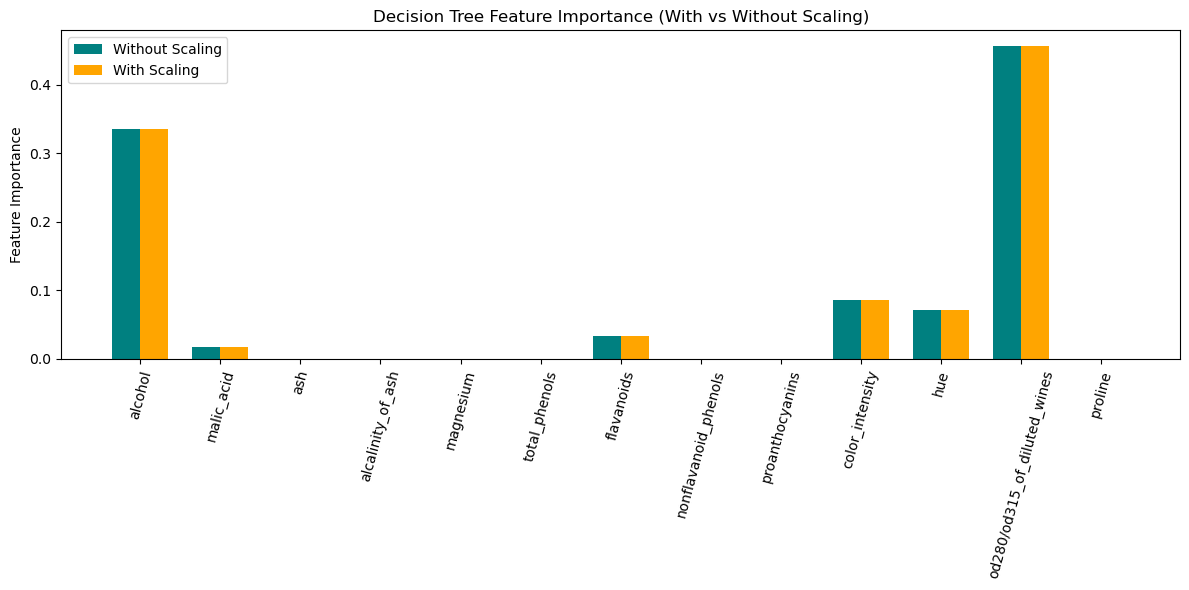

In [11]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Load dataset
data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ---- WITHOUT SCALING ----
clf_raw = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_raw.fit(X_train, y_train)
importance_raw = clf_raw.feature_importances_

# ---- WITH SCALING ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_scaled = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_scaled.fit(X_train_scaled, y_train)
importance_scaled = clf_scaled.feature_importances_

# ---- PLOT COMPARISON ----
x = np.arange(len(feature_names))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, importance_raw, width, label='Without Scaling', color='teal')
plt.bar(x + width/2, importance_scaled, width, label='With Scaling', color='orange')
plt.xticks(x, feature_names, rotation=75)
plt.ylabel('Feature Importance')
plt.title('Decision Tree Feature Importance (With vs Without Scaling)')
plt.legend()
plt.tight_layout()
plt.show()
